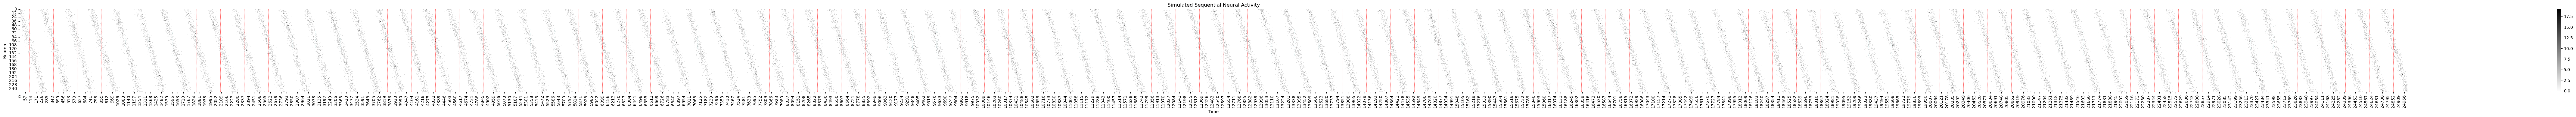

In [2]:
"""
Simulate a noisy sequential neural population activity pattern.

Rows    -> neurons (n = 250)
Columns -> time points

Each neuron is activated sequentially and repeatedly across time.
The underlying activity is smoothed with a Gaussian kernel and then
converted to spike-like observations using Poisson sampling.
Finally, activity is z-scored for each neuron.
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.ndimage import gaussian_filter1d


# --------------------------------------------------
# Parameters
# --------------------------------------------------
peak_value = 20          # Peak firing rate / activity amplitude
gaussian_sigma = 20      # Temporal smoothing width

n_neurons = 250          # Number of neurons
n_sequences = 100        # Number of repeated sequences
sequence_length = 250    # Length of one sequence

n_timepoints = n_sequences * sequence_length


# --------------------------------------------------
# Generate perfect sequential activity
# --------------------------------------------------
# Rows = neurons
# Columns = time points
simulated_data = np.zeros((n_neurons, n_timepoints))


for t in range(n_timepoints):
    neuron_idx = t % n_neurons
    simulated_data[neuron_idx, t] = peak_value


# --------------------------------------------------
# Temporal smoothing
# --------------------------------------------------
simulated_data = gaussian_filter1d(
    simulated_data,
    sigma=gaussian_sigma,
    axis=1
)


# --------------------------------------------------
# Generate spike-like observations
# --------------------------------------------------
simulated_data = np.random.poisson(simulated_data)



door_open_index = np.arange(n_sequences) * sequence_length + 100



# Z-score each neuron independently across time.
simulated_data = scipy.stats.zscore(simulated_data, axis=1)


# --------------------------------------------------
# Visualize simulated dataset
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(100, 4))

sns.heatmap(
    simulated_data,
    cmap="gray_r",
    ax=ax,
    cbar=True
)

# Overlay behavioral events
for e in door_open_index:
    ax.plot(
        [e, e],
        [0, n_neurons],
        color="red",
        linestyle="--",
        linewidth=0.4
    )

ax.set_title("Simulated Sequential Neural Activity")
ax.set_xlabel("Time")
ax.set_ylabel("Neuron")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Optional MATLAB export
# --------------------------------------------------
# scipy.io.savemat(
#     "Simulated_Data_Perfect_Sequence_Poisson.mat",
#     {
#         "s_diff": simulated_data,
#         "door_open_index": door_open_index
#     }
# )